# Past Data Factor Check — 精简版

- 三个核心表：Research / Realtime / Diff
- 预测值对比 + IC/RankIC 统计
- 夜盘归属下一交易日

> 只展开下面的「展示 cell」即可，工作逻辑已折叠在第一个 code cell 里。


In [1]:
# ========== 配置 + 导入 + 加载 + 对齐（非展示） ==========
SYMBOL = "P"

In [2]:
CONTRACT = f"{SYMBOL.lower()}2605"
DATES = ["2026-03-17", "2026-03-18", "2026-03-19", "2026-03-20", "2026-03-23"]
FILES_ROOT = "/home/strategy_PAMY_dev/files"
SAVE_FILES_ROOT = "/home/strategy_PAMY_dev/save_files"
MODEL_ROOT = "/home/strategy_PAMY_dev/models"
RESEARCH_FEATHER = f"/mnt/Data/writable/liaoyuyang/factor/{SYMBOL}/all_fac/all_factor.feather"
RESEARCH_1MIN = f"/mnt/Data/writable/liaoyuyang/data/1min/{SYMBOL}/{CONTRACT}.feather"
TAIL_N = 50
FORWARD_PERIOD = 1

# ========== 实时因子来源选择 ==========
# "save_files" : 从 save_files/{symbol}/factors/factors_*.csv 拼接（按分钟存，推荐）
# "files_recompute" : 从 files/*_tick.csv + *_min.csv 重新计算（验证计算逻辑用）
# "factor_cache" : 从 factor_cache/{date}/{symbol}_fac_*.parquet 读取
RT_SOURCE = "files_recompute"
FACTOR_CACHE_ROOT = "/home/strategy_PAMY_dev/factor_cache"
# =====================================

import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "/home/strategy_PAMY_dev")
import json, pandas as pd, numpy as np, lightgbm as lgb
from pathlib import Path
from data_function import load_fac_df_old, load_config
from strategies import (
    generate_factor_dataframe_A, generate_factor_dataframe_B,
    generate_factor_dataframe_C, generate_factor_dataframe_CS,
    generate_factor_dataframe_M, generate_factor_dataframe_P,
    generate_factor_dataframe_Y, generate_factor_dataframe_LH,
)

GENERATE_FUNC_MAP = {"A": generate_factor_dataframe_A, "B": generate_factor_dataframe_B,
    "C": generate_factor_dataframe_C, "CS": generate_factor_dataframe_CS,
    "M": generate_factor_dataframe_M, "Y": generate_factor_dataframe_Y,
    "P": generate_factor_dataframe_P, "LH": generate_factor_dataframe_LH}
CONTRACT_MAP = {"A":"a2605","B":"b2605","C":"c2605","CS":"cs2605",
    "M":"m2605","Y":"y2605","P":"p2605","LH":"lh2605"}
OTHER_SYMBOLS_MAP = {"A":["B","C","CS","M","Y","P","LH"],
    "B":["A","C","CS","M","Y","P","LH"],
    "C":["A","B","CS","M","Y","P","LH"],
    "CS":["A","B","C","M","Y","P","LH"],
    "M":["A","B","C","CS","Y","P","LH"],
    "Y":["A","B","C","CS","M","P","LH"],
    "P":["A","B","C","CS","M","Y","LH"],
    "LH":["A","B","C","CS","M","Y","P"]}

target_dates = [pd.to_datetime(d).date() for d in DATES]

# ---- 1min close（供IC用） ----
mkt_rs = pd.read_feather(RESEARCH_1MIN)
mkt_rs['datetime'] = pd.to_datetime(mkt_rs['ts'])
mkt_rs['trade_date_dt'] = mkt_rs['trade_date'].dt.date if hasattr(mkt_rs['trade_date'],'dt') else pd.to_datetime(mkt_rs['trade_date']).dt.date
mkt_rs = mkt_rs[mkt_rs['trade_date_dt'].isin(target_dates)].set_index('datetime')

# ---- 研究环境因子 ----
import pyarrow.feather as feather
schema = feather.read_table(RESEARCH_FEATHER).schema
rs_all = pd.read_feather(RESEARCH_FEATHER)
rs_all['datetime'] = pd.to_datetime(rs_all['datetime'])
rs_all['trade_date_dt'] = rs_all['datetime'].dt.date
inst = rs_all[rs_all['trade_date_dt'].isin(target_dates)]['instrument'].iloc[0]
fac_rs = rs_all[(rs_all['instrument']==inst) & (rs_all['trade_date_dt'].isin(target_dates))].copy()
del rs_all; fac_rs = fac_rs.set_index('datetime')

# ---- 实盘因子 ----
if RT_SOURCE == "save_files":
    # 从 save_files/{symbol}/factors/factors_*.csv 拼接
    fac_dir = Path(SAVE_FILES_ROOT) / SYMBOL / "factors"
    fac_files = sorted(fac_dir.glob("factors_*.csv"))
    if not fac_files:
        raise FileNotFoundError(f"未找到实时因子文件: {fac_dir}/factors_*.csv")
    print(f"[save_files] 发现 {len(fac_files)} 个 factors_*.csv 文件")
    
    fac_rt_parts = []
    for f in fac_files:
        df = pd.read_csv(f, parse_dates=['datetime'])
        fac_rt_parts.append(df)
    fac_rt_raw = pd.concat(fac_rt_parts, ignore_index=True)
    fac_rt_raw = fac_rt_raw.sort_values('datetime').drop_duplicates(subset=['datetime'], keep='last')
    fac_rt = fac_rt_raw.set_index('datetime')
    
    # 限制在目标日期
    fac_rt = fac_rt[fac_rt.index.normalize().isin(pd.to_datetime(DATES).date)].copy()
    print(f"[save_files] 拼接后共 {len(fac_rt)} 行, 列数 {len(fac_rt.columns)}")

elif RT_SOURCE == "factor_cache":
    cache_root = Path(FACTOR_CACHE_ROOT)
    cache_dates = sorted([d.name for d in cache_root.iterdir() if d.is_dir()])
    fac_rt_parts = []
    for d in cache_dates:
        for f in sorted((cache_root / d).glob(f"{SYMBOL}_fac_*.parquet")):
            fac_rt_parts.append(pd.read_parquet(f))
    fac_rt = pd.concat(fac_rt_parts).sort_index()
    if 'datetime' in fac_rt.columns:
        fac_rt = fac_rt.set_index('datetime').sort_index()
    fac_rt = fac_rt[fac_rt.index.normalize().isin(pd.to_datetime(DATES).date)].copy()
    print(f"[factor_cache] 拼接后共 {len(fac_rt)} 行")

else:  # "files_recompute"
    cfg = load_config()
    trade_hours = cfg["symbol_specs"][SYMBOL]["trade_hours"]
    model = lgb.Booster(model_file=f"{MODEL_ROOT}/{SYMBOL}/kfold_fold1_0.lgb")
    factor_col = model.feature_name()
    main_contract = CONTRACT_MAP[SYMBOL]
    other_symbols = OTHER_SYMBOLS_MAP[SYMBOL]
    fac_rt = load_fac_df_old(
        factor_col=factor_col, instrument_list=[main_contract]+[CONTRACT_MAP[s] for s in other_symbols],
        recent_data_path=FILES_ROOT, trade_type=trade_hours,
        dict_keys=[SYMBOL]+other_symbols, generate_factor_dataframe=GENERATE_FUNC_MAP[SYMBOL])
    fac_rt = fac_rt[fac_rt.index.normalize().isin(pd.to_datetime(DATES).date)].copy()
    print(f"[files_recompute] 重新计算后共 {len(fac_rt)} 行")

# ---- 对齐 ----
drop_cols = {"datetime","instrument","hour"}
common_factors = sorted((set(fac_rt.columns)-drop_cols) & (set(fac_rs.columns)-drop_cols))
fac_idx = fac_rt.index.intersection(fac_rs.index)
rt = fac_rt.loc[fac_idx, common_factors]
rs = fac_rs.loc[fac_idx, common_factors]

# ---- 预测值 ----
model_lst, weight_lst = [], []
for i in range(1,6):
    m = lgb.Booster(model_file=f"{MODEL_ROOT}/{SYMBOL}/kfold_fold{i}_0.lgb")
    with open(f'{MODEL_ROOT}/{SYMBOL}/kfold_fold{i}_0_meta.json') as f:
        meta_data=json.load(f)
    model_lst.append(m); weight_lst.append(float(np.log(meta_data['best_iteration']+1)))

pred_idx = fac_rt.index.intersection(fac_rs.index)
rt_input = fac_rt.loc[pred_idx, common_factors]
rs_input = fac_rs.loc[pred_idx, [c for c in common_factors if c in fac_rs.columns]].copy()
if 'hour' not in rs_input.columns: rs_input['hour']=rs_input.index.hour
# 用 model feature_name 过滤
factor_col = model_lst[0].feature_name()
rt_input = rt_input[[c for c in factor_col if c in rt_input.columns]].copy()
if 'hour' not in rt_input.columns: rt_input['hour'] = rt_input.index.hour
rs_input = rs_input[[c for c in factor_col if c in rs_input.columns]].copy()
if 'hour' not in rs_input.columns: rs_input['hour'] = rs_input.index.hour
rt_input = rt_input[factor_col]
rs_input = rs_input[factor_col]

pred_rt = pd.DataFrame([m.predict(rt_input) for m in model_lst], columns=rt_input.index).T
pred_rt['weighted'] = pred_rt.mul(weight_lst,axis=1).sum(axis=1)/sum(weight_lst)
pred_rt['weighted_s'] = pred_rt['weighted']*0.6 + pred_rt['weighted'].shift(1)*0.3 + pred_rt['weighted'].shift(2)*0.1

pred_rs = pd.DataFrame([m.predict(rs_input) for m in model_lst], columns=rs_input.index).T
pred_rs['weighted'] = pred_rs.mul(weight_lst,axis=1).sum(axis=1)/sum(weight_lst)
pred_rs['weighted_s'] = pred_rs['weighted']*0.6 + pred_rs['weighted'].shift(1)*0.3 + pred_rs['weighted'].shift(2)*0.1

print(f"All data ready. rt={len(rt)} rows, rs={len(rs)} rows, common_factors={len(common_factors)}")
print(f"pred_rt={len(pred_rt)}, pred_rs={len(pred_rs)}")


2026-03-16 21:01:00 - 2026-03-23 15:00:00
(1725, 267)
[files_recompute] 重新计算后共 1605 行
All data ready. rt=1605 rows, rs=1605 rows, common_factors=266
pred_rt=1605, pred_rs=1605


In [3]:
# Research factor table
rs.tail(TAIL_N).T.sort_index().round(8)

datetime,2026-03-23 14:11:00,2026-03-23 14:12:00,2026-03-23 14:13:00,2026-03-23 14:14:00,2026-03-23 14:15:00,2026-03-23 14:16:00,2026-03-23 14:17:00,2026-03-23 14:18:00,2026-03-23 14:19:00,2026-03-23 14:20:00,...,2026-03-23 14:51:00,2026-03-23 14:52:00,2026-03-23 14:53:00,2026-03-23 14:54:00,2026-03-23 14:55:00,2026-03-23 14:56:00,2026-03-23 14:57:00,2026-03-23 14:58:00,2026-03-23 14:59:00,2026-03-23 15:00:00
A_P_closepctchg20_sub,-0.004067,-0.003262,-0.002603,-0.003015,-0.003002,-0.003802,-0.003021,-0.002600,-0.003197,-0.003004,...,0.001015,-0.000218,-0.000210,-0.000452,-0.001644,-0.001216,0.000420,0.001626,0.000822,0.000419
A_P_closepctchg5_sub,-0.002115,-0.002510,-0.002286,-0.002689,-0.000427,-0.000967,-0.000798,-0.000168,-0.000756,-0.000144,...,0.000839,-0.000589,-0.000387,-0.001846,-0.002652,-0.002644,-0.001225,-0.000201,0.000856,0.000830
A_P_cvcorr10_diff,-0.807916,-0.744669,-0.366937,0.173084,0.312240,-0.437665,-0.542866,-0.524179,-0.943691,-0.790710,...,0.292921,0.325143,0.203203,0.507243,-0.532154,-0.555183,-0.584695,-0.703008,-0.352619,-0.285574
A_P_oi5_diff,-0.002194,-0.000615,-0.000688,-0.000764,-0.000334,-0.000497,-0.001799,-0.001725,-0.002041,-0.003601,...,0.002169,0.001349,0.000309,-0.000361,-0.000278,-0.000062,0.001089,0.001715,0.001906,0.003273
A_P_vcorr10,0.029308,-0.004289,-0.023747,-0.009930,0.152576,-0.318169,-0.324036,-0.313927,-0.363129,-0.152490,...,0.033561,0.170090,0.175370,0.227385,0.070752,0.260080,0.118022,0.177224,0.172671,0.598084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
down_shadow_5mean,1.733333,2.000000,0.457143,0.323810,0.457143,0.457143,0.279365,0.279365,0.315729,0.239538,...,1.226667,1.306667,0.773333,0.506667,0.377436,0.777436,0.811722,0.589499,0.749499,0.718730
lastprice_bias1,0.199115,0.295964,0.267857,0.196507,0.196429,0.237288,0.230089,0.208696,0.260684,0.311966,...,0.179825,0.169014,0.210526,0.154185,0.266949,0.237885,0.262931,0.333333,0.228448,0.245763
up_shadow_5mean,0.266667,0.533333,0.590476,0.457143,0.590476,0.590476,0.368254,0.368254,0.234921,0.158730,...,2.133333,2.133333,1.333333,1.440000,1.470769,0.270769,0.327912,0.372357,0.212357,0.410159
volatility_rg,1.075000,0.991667,1.050000,1.108333,1.108333,1.175000,1.175000,1.100000,1.033333,1.016667,...,0.916667,0.916667,0.858333,0.800000,0.825000,1.025000,1.025000,1.025000,1.025000,1.025000


In [4]:
# Realtime factor table
rt.tail(TAIL_N).T.sort_index()


datetime,2026-03-23 14:11:00,2026-03-23 14:12:00,2026-03-23 14:13:00,2026-03-23 14:14:00,2026-03-23 14:15:00,2026-03-23 14:16:00,2026-03-23 14:17:00,2026-03-23 14:18:00,2026-03-23 14:19:00,2026-03-23 14:20:00,...,2026-03-23 14:51:00,2026-03-23 14:52:00,2026-03-23 14:53:00,2026-03-23 14:54:00,2026-03-23 14:55:00,2026-03-23 14:56:00,2026-03-23 14:57:00,2026-03-23 14:58:00,2026-03-23 14:59:00,2026-03-23 15:00:00
A_P_closepctchg20_sub,-0.004067,-0.003262,-0.002603,-0.003015,-0.003002,-0.003802,-0.003021,-0.002600,-0.003197,-0.003004,...,0.001015,-0.000218,-0.000210,-0.000452,-0.001644,-0.001216,0.000420,0.001626,0.000822,0.000419
A_P_closepctchg5_sub,-0.002115,-0.002510,-0.002286,-0.002689,-0.000427,-0.000967,-0.000798,-0.000168,-0.000756,-0.000144,...,0.000839,-0.000589,-0.000387,-0.001846,-0.002652,-0.002644,-0.001225,-0.000201,0.000856,0.000830
A_P_cvcorr10_diff,-0.807916,-0.744669,-0.366937,0.173084,0.312240,-0.437665,-0.542866,-0.524179,-0.943691,-0.790710,...,0.292921,0.325143,0.203202,0.507243,-0.532154,-0.555183,-0.584695,-0.703008,-0.352619,-0.285574
A_P_oi5_diff,-0.002194,-0.000615,-0.000688,-0.000764,-0.000334,-0.000497,-0.001799,-0.001725,-0.002041,-0.003601,...,0.002169,0.001349,0.000309,-0.000361,-0.000278,-0.000062,0.001089,0.001715,0.001906,0.003273
A_P_vcorr10,0.029308,-0.004289,-0.023747,-0.009930,0.152576,-0.318169,-0.324036,-0.313927,-0.363129,-0.152490,...,0.033561,0.170090,0.175370,0.227385,0.070752,0.260080,0.118022,0.177224,0.172671,0.598084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
down_shadow_5mean,1.733333,2.000000,0.457143,0.323810,0.457143,0.457143,0.279365,0.279365,0.315729,0.239538,...,1.226667,1.306667,0.773333,0.506667,0.377436,0.777436,0.811722,0.589499,0.749499,0.718730
lastprice_bias1,0.199115,0.295964,0.267857,0.196507,0.196429,0.237288,0.230089,0.208696,0.260684,0.311966,...,0.179825,0.169014,0.210526,0.154185,0.266949,0.237885,0.262931,0.333333,0.228448,0.245763
up_shadow_5mean,0.266667,0.533333,0.590476,0.457143,0.590476,0.590476,0.368254,0.368254,0.234921,0.158730,...,2.133333,2.133333,1.333333,1.440000,1.470769,0.270769,0.327912,0.372357,0.212357,0.410159
volatility_rg,1.075000,0.991667,1.050000,1.108333,1.108333,1.175000,1.175000,1.100000,1.033333,1.016667,...,0.916667,0.916667,0.858333,0.800000,0.825000,1.025000,1.025000,1.025000,1.025000,1.025000


In [5]:
# Factor diff table（fillna 142857 trick）
def filter_active_trading(df):
    t = df.index.time
    return df[
        ((t >= pd.Timestamp("09:10").time()) & (t <= pd.Timestamp("10:05").time())) |
        ((t >= pd.Timestamp("10:40").time()) & (t <= pd.Timestamp("11:20").time())) |
        ((t >= pd.Timestamp("13:40").time()) & (t <= pd.Timestamp("14:50").time())) |
        ((t >= pd.Timestamp("21:10").time()) & (t <= pd.Timestamp("22:50").time()))
    ]
rt_tail = filter_active_trading(rt.tail(TAIL_N)); rs_tail = rs.reindex_like(rt_tail)
(rt_tail.fillna(142857) - rs_tail.fillna(142857)).T.round(4).sort_index()


datetime,2026-03-23 14:11:00,2026-03-23 14:12:00,2026-03-23 14:13:00,2026-03-23 14:14:00,2026-03-23 14:15:00,2026-03-23 14:16:00,2026-03-23 14:17:00,2026-03-23 14:18:00,2026-03-23 14:19:00,2026-03-23 14:20:00,...,2026-03-23 14:41:00,2026-03-23 14:42:00,2026-03-23 14:43:00,2026-03-23 14:44:00,2026-03-23 14:45:00,2026-03-23 14:46:00,2026-03-23 14:47:00,2026-03-23 14:48:00,2026-03-23 14:49:00,2026-03-23 14:50:00
A_P_closepctchg20_sub,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,...,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0
A_P_closepctchg5_sub,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0
A_P_cvcorr10_diff,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
A_P_oi5_diff,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,...,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0
A_P_vcorr10,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,...,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
down_shadow_5mean,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0
lastprice_bias1,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,...,-0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0
up_shadow_5mean,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,...,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0
volatility_rg,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0


In [6]:
# Prediction diff (weighted / weighted_s)
diff_w = (pred_rt['weighted'] - pred_rs['weighted']).abs()
diff_ws = (pred_rt['weighted_s'] - pred_rs['weighted_s']).abs()
print(f'weighted   max={diff_w.max():.4f} mean={diff_w.mean():.4f}')
print(f'weighted_s max={diff_ws.max():.4f} mean={diff_ws.mean():.4f}')
diff_df = pd.DataFrame({
    'rt_w': pred_rt['weighted'], 'rs_w': pred_rs['weighted'], 'diff_w': diff_w,
    'rt_ws': pred_rt['weighted_s'], 'rs_ws': pred_rs['weighted_s'], 'diff_ws': diff_ws,
}).round(3)
diff_df.tail(TAIL_N)

weighted   max=0.0355 mean=0.0027
weighted_s max=0.0338 mean=0.0026


,rt_w,rs_w,diff_w,rt_ws,rs_ws,diff_ws
datetime,,,,,,
2026-03-23 14:11:00,0.029,0.028,0.000,0.024,0.023,0.0
2026-03-23 14:12:00,0.011,0.011,0.000,0.017,0.017,0.0
2026-03-23 14:13:00,0.022,0.022,0.000,0.019,0.019,0.0
2026-03-23 14:14:00,0.018,0.018,0.000,0.018,0.019,0.0
2026-03-23 14:15:00,0.036,0.036,0.000,0.029,0.030,0.0
2026-03-23 14:16:00,0.014,0.014,0.000,0.021,0.021,0.0
2026-03-23 14:17:00,0.009,0.009,0.001,0.013,0.014,0.0
2026-03-23 14:18:00,0.013,0.013,0.000,0.012,0.012,0.0
2026-03-23 14:19:00,0.012,0.012,0.000,0.012,0.012,0.0


In [7]:
diff_df.tail(345).sort_values('diff_ws', key=abs, ascending=False).head(100)

,rt_w,rs_w,diff_w,rt_ws,rs_ws,diff_ws
datetime,,,,,,
2026-03-20 21:01:00,-0.016,-0.014,0.002,0.009,0.010,0.001
2026-03-23 11:17:00,0.018,0.019,0.002,0.004,0.005,0.001
2026-03-20 21:03:00,-0.003,-0.004,0.002,-0.004,-0.004,0.001
2026-03-23 09:18:00,0.042,0.041,0.001,0.044,0.044,0.001
2026-03-23 09:09:00,-0.015,-0.016,0.001,-0.001,-0.002,0.001
...,...,...,...,...,...,...
2026-03-20 21:30:00,0.003,0.003,0.000,0.012,0.012,0.000
2026-03-20 21:29:00,0.028,0.028,0.000,0.021,0.021,0.000
2026-03-20 21:28:00,0.010,0.010,0.000,0.011,0.011,0.000


<Axes: xlabel='datetime'>

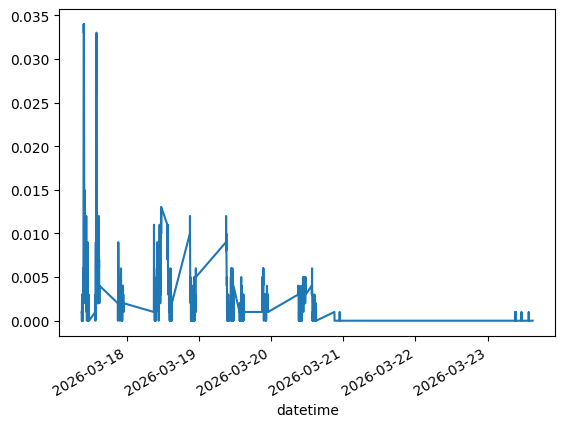

In [8]:
diff_df.diff_ws.plot()

In [9]:
# ========== 研究预测值 vs 实盘预测值 相关性 ==========
# 目标：两列预测值的相关系数越接近 1 越好，说明实盘复现误差小

pred_idx = pred_rs.index.intersection(pred_rt.index)
cmp = pd.DataFrame({
    'rs_w':  pred_rs.loc[pred_idx, 'weighted'],
    'rt_w':  pred_rt.loc[pred_idx, 'weighted'],
    'rs_ws': pred_rs.loc[pred_idx, 'weighted_s'],
    'rt_ws': pred_rt.loc[pred_idx, 'weighted_s'],
})
cmp['date'] = cmp.index.date

def calc_corr(g):
    g = g[['rs_w','rt_w','rs_ws','rt_ws']].dropna()
    if len(g) < 10:
        return pd.Series([np.nan]*4, index=['w_pearson','w_spearman','ws_pearson','ws_spearman'])
    return pd.Series([
        g['rs_w'].corr(g['rt_w']),
        g['rs_w'].corr(g['rt_w'], method='spearman'),
        g['rs_ws'].corr(g['rt_ws']),
        g['rs_ws'].corr(g['rt_ws'], method='spearman'),
    ], index=['w_pearson','w_spearman','ws_pearson','ws_spearman'])

daily_corr = cmp.groupby('date').apply(calc_corr)
print('=== Daily Correlation ===')
print(daily_corr.round(4).to_string())

summary = pd.DataFrame({
    'w_pearson':  [daily_corr['w_pearson'].mean(),  daily_corr['w_pearson'].std()],
    'w_spearman': [daily_corr['w_spearman'].mean(), daily_corr['w_spearman'].std()],
    'ws_pearson': [daily_corr['ws_pearson'].mean(), daily_corr['ws_pearson'].std()],
    'ws_spearman':[daily_corr['ws_spearman'].mean(),daily_corr['ws_spearman'].std()],
}, index=['mean','std'])
print('\n=== Overall Correlation Summary ===')
print(summary.round(4).to_string())

# 全局相关系数（不按日拆分）
print('\n=== Global Correlation ===')
print(f"weighted   pearson={cmp['rs_w'].corr(cmp['rt_w']):.6f}  spearman={cmp['rs_w'].corr(cmp['rt_w'],method='spearman'):.6f}")
print(f"weighted_s pearson={cmp['rs_ws'].corr(cmp['rt_ws']):.6f}  spearman={cmp['rs_ws'].corr(cmp['rt_ws'],method='spearman'):.6f}")


=== Daily Correlation ===
            w_pearson  w_spearman  ws_pearson  ws_spearman
date                                                      
2026-03-17     0.9239      0.9438      0.9175       0.9397
2026-03-18     0.9870      0.9784      0.9866       0.9756
2026-03-19     0.9930      0.9921      0.9929       0.9929
2026-03-20     0.9974      0.9967      0.9974       0.9969
2026-03-23     0.9999      0.9997      0.9999       0.9998

=== Overall Correlation Summary ===
      w_pearson  w_spearman  ws_pearson  ws_spearman
mean     0.9802      0.9821      0.9789       0.9810
std      0.0319      0.0229      0.0347       0.0249

=== Global Correlation ===
weighted   pearson=0.981932  spearman=0.982974
weighted_s pearson=0.980851  spearman=0.982771
